TP 2 : Clustering 
====

# 0 - Introduction

L'objectif de ce premier TP est d'étudier quelques techniques de Clustering.
Il sera à réaliser en python 3. Les librairies utilisées sont installées sur les machines de l'université et de l'Ensicaen, vous pouvez néanmoins les installer sur vos propres machines à l'aide de l'utilitaire pip présent par défaut avec python.
	
N'hésitez pas à regarder régulièrement la documentation de ces librairies, des exemples d'utilisation accompagnent généralement l'explication de chaque fonction.


Langage utilisé:
- Python 3: https://docs.python.org/3/

Librairie de math:
- Numpy: https://docs.scipy.org/doc/numpy/reference/
- Scipy: https://docs.scipy.org/doc/scipy/reference/

Librairie d'affichage de données:
- Matplotilb: https://matplotlib.org/contents.html

Librairie de traitement d'image:
- Scikit-image: https://scikit-image.org/

Librairie d'apprentissage automatique:
- Scikit-learn: http://scikit-learn.org

**Afin d'avoir un code optimisé, vous éviterez d'utiliser les instructions python3 `if`, `for` et `while` (sauf mention contraire dans le sujet).**

In [1]:
#Ce bloc contient tous les imports nécessaires pour ce TP.

# import de fonctions mathématiques
import numpy as np
import scipy as sc

# import fonction d'affichage
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D # pour la gestion de figure 3D
import matplotlib.patches as mpatches

# import librairies d'apprentissage automatique
import sklearn as skl
import sklearn.datasets as data
import sklearn.cluster
import sklearn.mixture

Afin de vous guider dans la détection d'erreur dans votre code. Nous avons introduit des blocs de tests. Il n'est pas nécessaire que vous compreniez en détail le code de ces blocs. Vous devez uniquement les exécuter et corriger les erreurs de votre code si un des tests n'est pas valide. Il est important de noter que le fait de valider le test ne garantit pas que votre code ne contient pas d'erreur. Par contre un test non validé implique nécessairement que votre code contient une erreur.

- Si tout les tests sont valides, vous aurez un message écrit en vert indiquant : Ok - Tous les tests sont validés.
- Si un des tests n'est pas valide, vous aurez un message écrit en rouge indiquant : Au moins un test n'est pas validé.
- Pour les tests non valides, vous aurez des éléments d'information sur le test non valide. En particulier, un message écrit en jaune vous détaillera la nature du test échoué.

Voici un exemple d'utilisation. Le bloc suivant est censé contenir l'affectation de la valeur 42 à la variable `a`. Le bloc de test d'après vérifie que vous avez correctement effectué l'affectation. Exécutez les deux blocs avec des valeurs de `a` correcte et incorrecte.
Vous devez supprimer la ligne `raise NotImplementedError()` qui indique que vous n'avez pas encore fait l'implémentation.

In [2]:
# YOUR CODE HERE
a = 42

In [3]:
# Ce bloc permet de valider votre code. Vous ne devez pas le modifier.  
try:
    np.testing.assert_equal(a,42,err_msg="\033[93m {}\033[00m" .format('Test 1 : a n\'est pas égale à 42. Vérifiez que a==42'))
except Exception as e: 
    print("\033[91m {}\033[00m" .format('KO - Au moins un test n\'est pas validé')) 
    print('Information sur le test non valide:')
    print(e)
    raise e
else:
    print("\033[92m {}\033[00m" .format('Ok - Tous les tests sont validés.')) 

 Ok - Tous les tests sont validés.


1 - Génération de données
---

Dans cette première partie nous allons générer des données selon 3 Gaussiennes sphériques. Vous utiliserez pour cela la fonction `np.random.normal`. Les caractéristiques des 3 gausiennes sont les suivantes:
- 500 points selon une distribution gaussienne centrée sur le point [0,2], d'écart type 0.1,
- 100 points selon une distribution gaussienne centrée sur le point [-1,0], d'écart type 0.05
- 50  points selon une distribution gaussienne centrée sur le point [1,0], d'écart type 0.05

In [4]:
def gen_3_gausiennes():
    '''
    :return: retourne trois matrices correspondant au trois gausiennes dans l'ordre de la question
    '''
    # YOUR CODE HERE
    g1 = np.random.normal(loc=[0, 2], scale=0.1, size=(500, 2))
    g2 = np.random.normal(loc=[-1, 0], scale=0.05, size=(100, 2))
    g3 = np.random.normal(loc=[1, 0], scale=0.05, size=(50, 2))
    return g1,g2,g3

In [5]:
# Ce bloc permet de valider votre code. Vous ne devez pas le modifier.  
try:
    g1,g2,g3 = gen_3_gausiennes()
    np.testing.assert_equal(g1.shape,(500,2),err_msg="\033[93m {}\033[00m" .format('Test 1 : le nombre de point généré par la première gaussienne est incorrect.'))
    np.testing.assert_equal(g2.shape,(100,2),err_msg="\033[93m {}\033[00m" .format('Test 2 : le nombre de point généré par la deuxième gaussienne est incorrect.'))
    np.testing.assert_equal(g3.shape,(50,2),err_msg="\033[93m {}\033[00m" .format('Test 3 : le nombre de point généré par la troisième gaussienne est incorrect.'))
        
except Exception as e: 
    print("\033[91m {}\033[00m" .format('KO - Au moins un test n\'est pas validé')) 
    print('Information sur le test non valide:')
    print(e)
    raise e
else:
    print("\033[92m {}\033[00m" .format('Ok - Tous les tests sont validés.')) 
    

del g1,g2,g3

 Ok - Tous les tests sont validés.


Écrivez une fonction qui génére les points selon les trois gausiennes et les concaténe dans une seule matrice. Pour rappel les fonctions de concaténation de `numpy` sont listé à l'adresse : https://numpy.org/doc/stable/reference/routines.array-manipulation.html#joining-arrays

In [6]:
def gen_pts():
    # YOUR CODE HERE
    g1,g2,g3 = gen_3_gausiennes()
    X = np.concatenate((g1,g2,g3))
    return X

X = gen_pts()

In [7]:
# Ce bloc permet de valider votre code. Vous ne devez pas le modifier.  
try:
    np.testing.assert_equal(gen_pts().shape,(650,2),err_msg="\033[93m {}\033[00m" .format('Test 1 : les dimensions de X ne sont pas correcte.'))
        
except Exception as e: 
    print("\033[91m {}\033[00m" .format('KO - Au moins un test n\'est pas validé')) 
    print('Information sur le test non valide:')
    print(e)
    raise e
else:
    print("\033[92m {}\033[00m" .format('Ok - Tous les tests sont validés.')) 

 Ok - Tous les tests sont validés.


Affichez à l'aide de `matplotlib` les points de la question précédente.

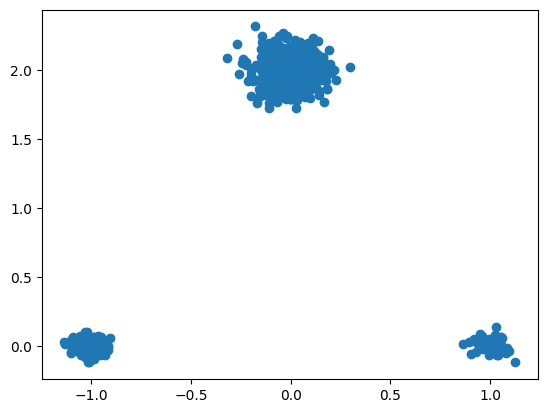

In [8]:
# YOUR CODE HERE
def plot_pts(X):
    plt.scatter(X[:,0],X[:,1])
    plt.show()
plot_pts(X)

Créez un vecteur de label (nommé `labels`) contenant le numéro de la gausienne qui a permis de généré chaque point. La première gaussienne a le numéro 0.

In [9]:
# YOUR CODE HERE
labels = np.zeros(650)
labels[500:600] = 1
labels[600:] = 2

print("premiers pts de X:", X[:5])
print("premiers labels:", labels[:10])


premiers pts de X: [[ 0.04066986  1.92235   ]
 [-0.14573744  1.84584307]
 [ 0.05803536  1.99927752]
 [-0.05738265  2.24796611]
 [ 0.21685257  2.00025731]]
premiers labels: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [10]:
# Ce bloc permet de valider votre code. Vous ne devez pas le modifier.  
try:
    np.testing.assert_equal(labels.shape,(650,),err_msg="\033[93m {}\033[00m" .format('Test 1 : la dimension du vecteur labels n\'est pas correcte.'))
    np.testing.assert_equal(np.all(labels[:500]==0),True,err_msg="\033[93m {}\033[00m" .format('Test 2 : Les labels de la gaussienne 0 sont incorrects'))
    np.testing.assert_equal(np.all(labels[500:600]==1),True,err_msg="\033[93m {}\033[00m" .format('Test 2 : Les labels de la gaussienne 1 sont incorrectes'))
    np.testing.assert_equal(np.all(labels[600:]==2),True,err_msg="\033[93m {}\033[00m" .format('Test 2 : Les labels de la gaussienne 2 sont incorrectes'))
        
except Exception as e: 
    print("\033[91m {}\033[00m" .format('KO - Au moins un test n\'est pas validé')) 
    print('Information sur le test non valide:')
    print(e)
    raise e
else:
    print("\033[92m {}\033[00m" .format('Ok - Tous les tests sont validés.')) 

 Ok - Tous les tests sont validés.


En utilisant `X`, `labels` et les paramètres de la fonction `plt.scatter` affichez les points générés avec une couleur différente par gausienne.

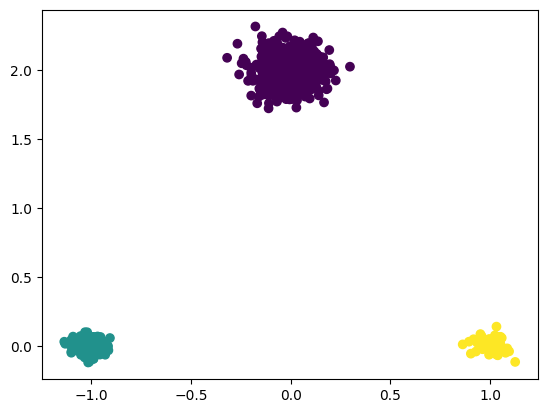

In [11]:
# YOUR CODE HERE
def plot_pts_labels(X,labels):
    plt.scatter(X[:,0],X[:,1],c=labels)
    plt.show()
plot_pts_labels(X,labels)

2 - Clustering par K-Moyennes
---

Nous allons dans cette partie utiliser l'implémentation de `scikit-learn` de l'algoritheme des K-Moyennes et en étudier les paramètres. 
Commencez par lire la documentation sur le sujet : https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

L'algorithme des K-Moyennes peut être initialisé de plusieurs façon. Faites un apprentissage en partant des trois points suivants : 
- -0.4  ;  2.75
- 0 ;  2.75
- 0.3  ; 2.5

Vous mettrez le paramètre `n_init` à 1.

In [12]:
def get_K_Means_with_spetial_init(X):
    '''
    :param X: données uitilisées pour apprendre le Kmeans
    :return: retourne l'objet appris à l'aide d'un Kmeans sur les données X passé en argument de la fonction. L'algorithme est initialisé avec 3 centres fixés.
    '''
    # YOUR CODE HERE
    kmeans = sklearn.cluster.KMeans(n_clusters=3, init=np.array([[-0.4, 2.75], [0, 2.75], [0.3, 2.5]]), n_init=1)
    kmeans.fit(X)
    return kmeans



In [13]:
# Ce bloc permet de valider votre code. Vous ne devez pas le modifier.  
try:
    _kmeans_ = get_K_Means_with_spetial_init(X)
    
    np.testing.assert_equal(type(_kmeans_),sklearn.cluster._kmeans.KMeans,err_msg="\033[93m {}\033[00m" .format('Test 1 : l\'objet retourné par la fonction get_K_Means_with_spetial_init n\'est pas correct.'))
    try:
        assert 'n_iter_' in _kmeans_.__dict__
    except Exception as e: 
        raise AssertionError("Test 2 : L'algorithme Kmeans n'a pas été appris.")
except Exception as e: 
    print("\033[91m {}\033[00m" .format('KO - Au moins un test n\'est pas validé')) 
    print('Information sur le test non valide:')
    print(e)
    raise e
else:
    print("\033[92m {}\033[00m" .format('Ok - Tous les tests sont validés.')) 
    

 Ok - Tous les tests sont validés.


Affichez sur une même figure:
- les points dans `X`
- les 3 points de départs
- la position finales des 3 clusters.

Vous utiliserez des couleurs différentes pour différencier ces points.

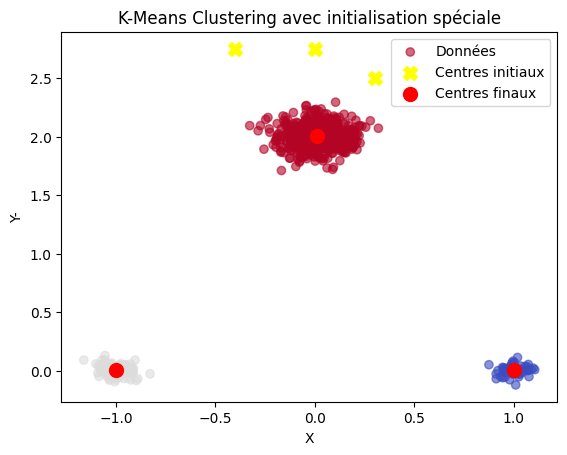

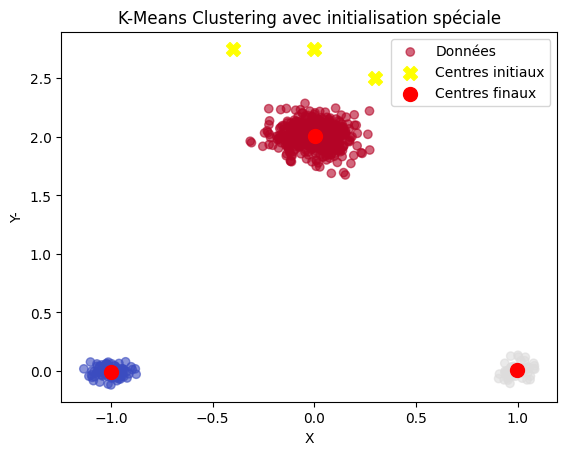

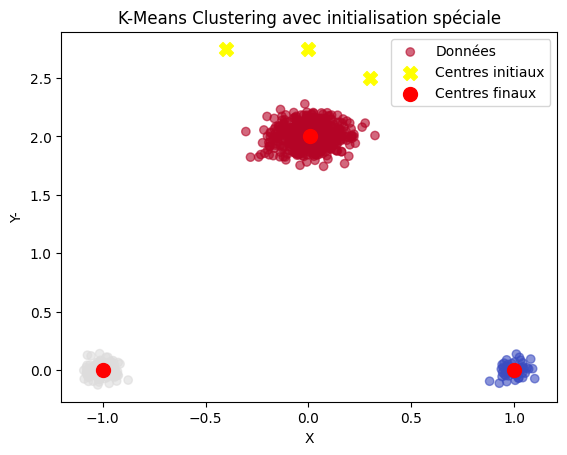

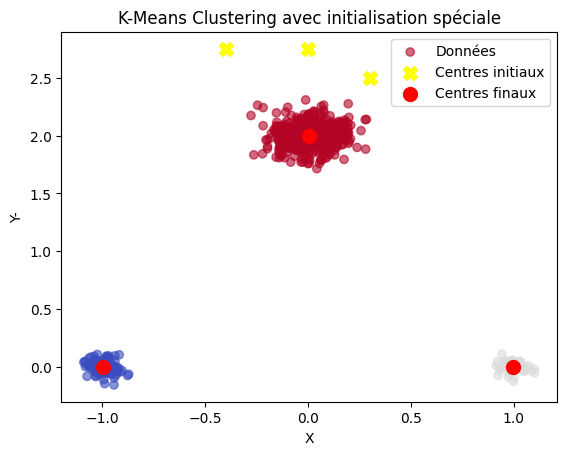

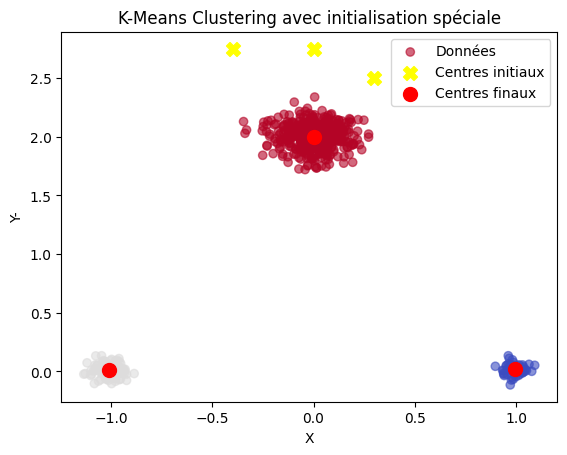

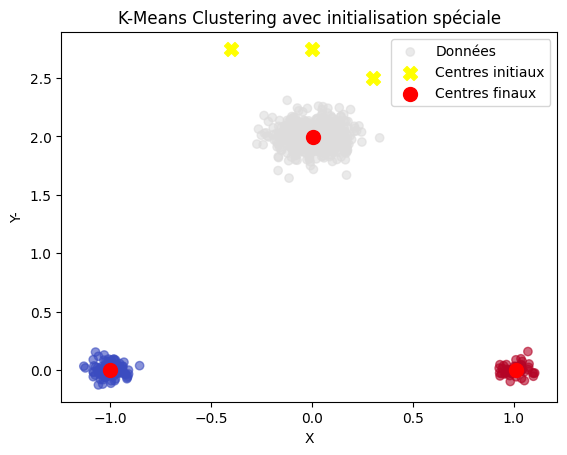

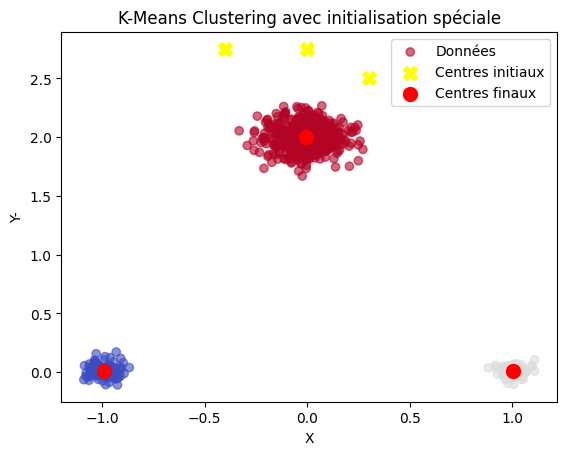

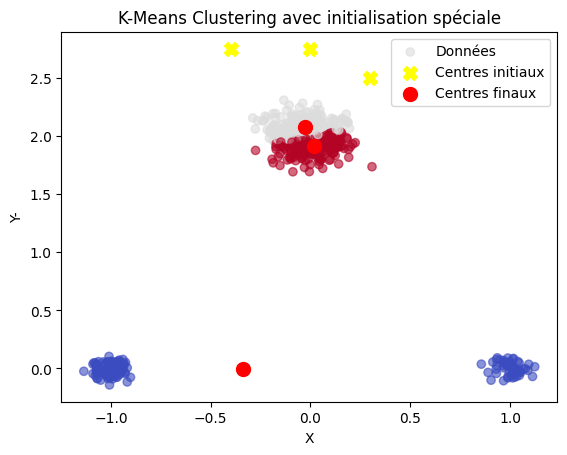

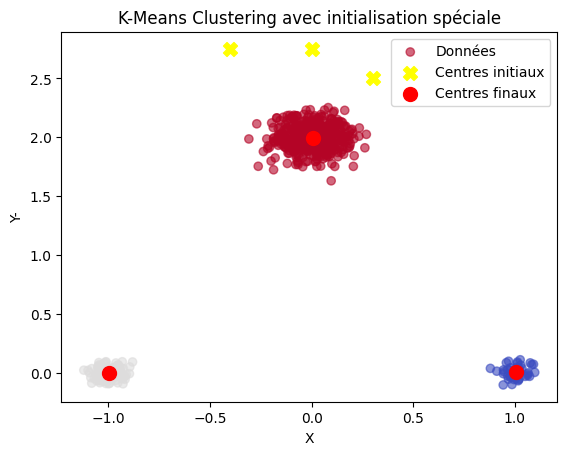

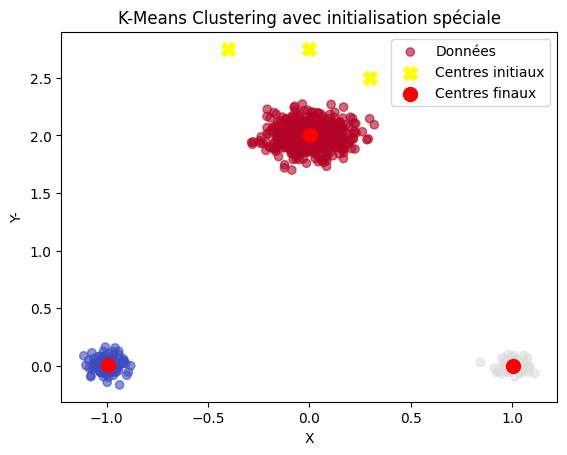

In [14]:
# def plot_kmeans_with_spetial_init(X):
#     # YOUR CODE HERE
#     kmeans = get_K_Means_with_spetial_init(X)
#     plt.scatter(X[:,0],X[:,1],c=kmeans.labels_)
#     plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],c='red',s=100)
#     plt.show()

def plot_kmeans_with_spetial_init(X):
    
    kmeans = get_K_Means_with_spetial_init(X)    
    plt.scatter(X[:,0], X[:,1], c=kmeans.labels_, cmap='coolwarm', alpha=0.6, label='Données')
    initial_centers = np.array([[-0.4, 2.75], [0, 2.75], [0.3, 2.5]])
    plt.scatter(initial_centers[:,0], initial_centers[:,1], c='yellow', marker='X', s=100, label='Centres initiaux')
    plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', s=100, label='Centres finaux')
    plt.xlabel("X")
    plt.ylabel("Y-")
    plt.title("K-Means Clustering avec initialisation spéciale")
    plt.legend()
    plt.show()
    
# 10 clustering avec des points différents. Que pouvez-vous remarquer ? Pourquoi ? 
for i in range(10):
    X = gen_pts()
    plot_kmeans_with_spetial_init(X)
    

Exécutez le code suivant pour visualiser les cellules de Voronoï de chaque cluster.

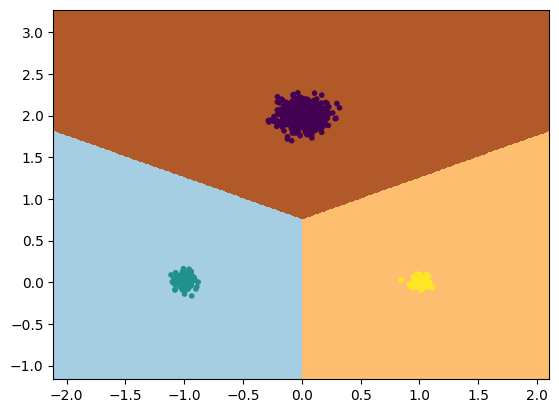

In [15]:
kmeans = get_K_Means_with_spetial_init(X)

def affichage_cellules_Voronoi(clf,X,labels):
    '''
    Fonction affichant les cellules de Voronoi d'un algorithme de clustering préalablement appris
    :param clf: classifieur non supervisé appris au préalable
    '''
    pas = 500 # pas de quantification, plus la valeur est grande plus les frontières sont précises mais le temps de calcul augmente

    x_min, x_max = X[:, 0].min() -1, X[:, 0].max() +1
    y_min, y_max = X[:, 1].min() -1 , X[:, 1].max() +1
    h = abs(x_max-x_min)/pas 
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = clf.predict(np.stack((xx.ravel(), yy.ravel()),1))
    Z = Z.reshape(xx.shape)

    plt.scatter(X[:,0],X[:,1],c=labels,marker='.')
    plt.imshow(Z, interpolation='nearest',
               extent=(xx.min(), xx.max(), yy.min(), yy.max()),
               cmap=plt.cm.Paired,
               aspect='auto', origin='lower')
    plt.show()
    
affichage_cellules_Voronoi(kmeans,X,labels)

Faites une étude de l'impacte des différentes paramètres possibles de Kmeans. Que font les autres méthodes d'initialisation ? Que se passe-t-il si on fait varier le nombre de classes recherchées ? ...

3 - Modèle de mélange de Gausiennes
-----

Nous allons dans cette partie réalisé un clustering à l'aide d'un mélange de Gausinnes (GMM: Gaussian Mixture Model). Pour cela veuillez étudiez la documentation à la page: https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html

De manière analogue à la partie précédente. Apprenez le mélange de Gaussiennes et affichez les cellules de Voronoï de chaque cluster.

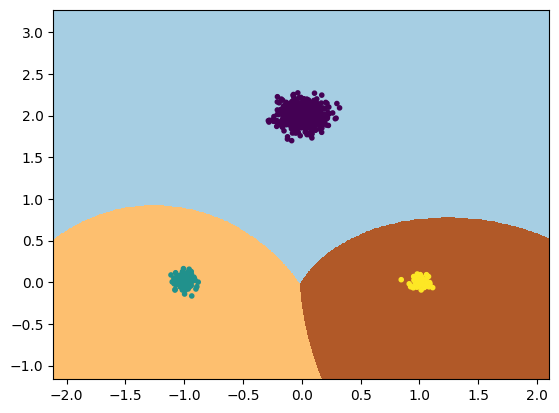

In [16]:
def get_GMM(X):
    '''
    :param X: données d'apprentissage
    :return : un GMM appris avec X
    '''
    # YOUR CODE HERE
    gmm = sklearn.mixture.GaussianMixture(n_components=3)
    gmm.fit(X)
    return gmm

# YOUR CODE HERE
gmm = get_GMM(X)
affichage_cellules_Voronoi(gmm,X,labels)

In [17]:
# Ce bloc permet de valider votre code. Vous ne devez pas le modifier.  
try:
    _gmm_ = get_GMM(X)
    
    np.testing.assert_equal(type(_gmm_),sklearn.mixture._gaussian_mixture.GaussianMixture,err_msg="\033[93m {}\033[00m" .format('Test 1 : l\'objet retourné par la fonction get_GMM n\'est pas correct.'))
    try:
        assert 'n_iter_' in _gmm_.__dict__
    except Exception as e: 
        raise AssertionError("Test 2 : L'algorithme GMM n'a pas été appris.")
except Exception as e: 
    print("\033[91m {}\033[00m" .format('KO - Au moins un test n\'est pas validé')) 
    print('Information sur le test non valide:')
    print(e)
    raise e
else:
    print("\033[92m {}\033[00m" .format('Ok - Tous les tests sont validés.')) 
    

 Ok - Tous les tests sont validés.


Les données que nous utilisons jusqu'à présent sont définis selon des clusters sphériques. Nous allons maintenant utiliser des données réparties selon des ellipses. Pour cela utilisez la fonction `np.random.multivariate_normal` ( https://numpy.org/doc/stable/reference/random/generated/numpy.random.multivariate_normal.html ).

Les caractéristiques des 3 lois normales sont les suivantes:
- 500 points selon une distribution normal centrée sur le point [4,6], de covariance $\left[\begin{array}{cc}
1&0.7\\
0.7&1
\end{array}
\right]
$,
- 100 points selon une distribution normal centrée sur le point [0,0], de covariance $\left[\begin{array}{cc}
0.7&-0.5\\
-0.5&0.7
\end{array}
\right]
$,
- 50  points selon une distribution normal centrée sur le point [7,2], de covariance $\left[\begin{array}{cc}
0.3&0\\
0&0.3
\end{array}
\right]
$.

In [18]:
# def gen_pts_3cluster_ellipse():
#     '''
#     :return : des points générer selon trois distributions normals elliptiques pré-définis.
#     '''
#     # YOUR CODE HERE
#     g1 = np.random.multivariate_normal(mean=[0, 0], cov=[[0.1, 0], [0, 0.1]], size=500)
#     g2 = np.random.multivariate_normal(mean=[0, 0], cov=[[0.1, 0], [0, 0.1]], size=100)
#     g3 = np.random.multivariate_normal(mean=[0, 0], cov=[[0.1, 0], [0, 0.1]], size=50)
#     X = np.concatenate((g1, g2, g3))
    
#     return X
def gen_pts_3cluster_ellipse():
    '''
    :return : des points générés selon trois distributions normales elliptiques pré-définies.
    '''
    cov1 = np.array([[1, 0.7], [0.7, 1]])
    cov2 = np.array([[0.7, -0.5], [-0.5, 0.7]])
    cov3 = np.array([[0.3, 0], [0, 0.3]])
    
    g1 = np.random.multivariate_normal(mean=[4, 6], cov=cov1, size=500)
    g2 = np.random.multivariate_normal(mean=[0, 0], cov=cov2, size=100)
    g3 = np.random.multivariate_normal(mean=[7, 2], cov=cov3, size=50)
    
    X = np.concatenate((g1, g2, g3))
    return X

X_ellipse = gen_pts_3cluster_ellipse()


In [19]:
# Ce bloc permet de valider votre code. Vous ne devez pas le modifier.  
try:
    X_ellipse = gen_pts_3cluster_ellipse()
    np.testing.assert_equal(X_ellipse.shape,(650,2),err_msg="\033[93m {}\033[00m" .format('Test 1 : le nombre de points générés est incorrect.'))
        
except Exception as e: 
    print("\033[91m {}\033[00m" .format('KO - Au moins un test n\'est pas validé')) 
    print('Information sur le test non valide:')
    print(e)
    raise e
else:
    print("\033[92m {}\033[00m" .format('Ok - Tous les tests sont validés.')) 
    

 Ok - Tous les tests sont validés.


Visualisez les points générés

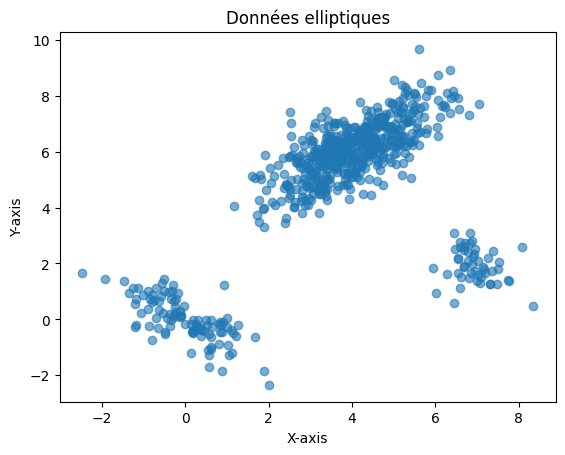

In [20]:
# YOUR CODE HERE
# def plot_3cluster_ellipse(X):
#     plt.scatter(X[:,0],X[:,1])
#     plt.show()
# plot_3cluster_ellipse(X_ellipse)

def plot_3cluster_ellipse(X):
    plt.scatter(X[:,0], X[:,1], alpha=0.6)
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.title("Données elliptiques")
    plt.show()
plot_3cluster_ellipse(X_ellipse)

Comparez l'algorithme des K-moyennes et le GMM sur ces nouvelles données.

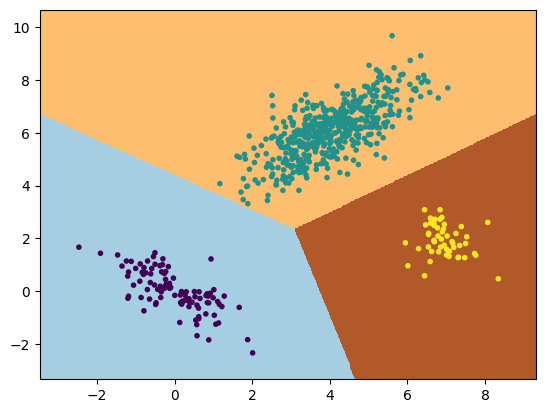

In [21]:
# YOUR CODE HERE
# def get_GMM_3cluster_ellipse(X):
#     '''
#     :param X: données d'apprentissage
#     :return : un GMM appris avec X
#     '''
#     # YOUR CODE HERE
#     gmm = sklearn.mixture.GaussianMixture(n_components=3)
#     gmm.fit(X)
#     return gmm
# gmm = get_GMM_3cluster_ellipse(X)
# affichage_cellules_Voronoi(gmm,X,labels)
kmeans_model = get_K_Means_with_spetial_init(X_ellipse)

kmeans_labels = kmeans_model.labels_

affichage_cellules_Voronoi(kmeans_model,X_ellipse,kmeans_labels)

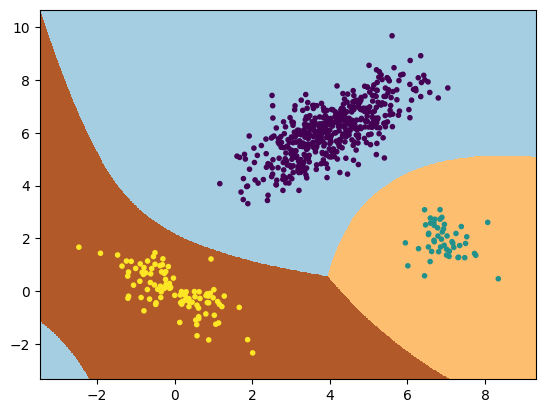

In [22]:
gmm_model = get_GMM(X_ellipse)

gmm_labels = gmm_model.predict(X_ellipse)

affichage_cellules_Voronoi(gmm_model,X_ellipse,gmm_labels)

4 - Clustering Spectral
------

Nous allons dans cette partie réalisé un clustering à l'aide d'un clustering Spectral. Pour cela veuillez étudiez la documentation à la page: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html

Ecrivez un code fessant le clustering spectral de données en utilisant comme `eigen_solver` l'algorithme `arpack` et comme `affinity` un graphe des plus proches voisins. Nous visualiserons le résultat dans la question suivante.

In [23]:
def get_spectral_clustering(X):
    '''
    :param X: données d'apprentissage
    :return : un clustering spectral sur les données X
    '''
    spectre = sklearn.cluster.SpectralClustering(n_clusters=3, eigen_solver='arpack', affinity='nearest_neighbors')
    spectre.fit(X)
    return spectre


In [24]:
# Ce bloc permet de valider votre code. Vous ne devez pas le modifier.  
try:
    X_ellipse = gen_pts_3cluster_ellipse()
    _spectral_ = get_spectral_clustering(X_ellipse)
    
    np.testing.assert_equal(type(_spectral_),sklearn.cluster._spectral.SpectralClustering,err_msg="\033[93m {}\033[00m" .format('Test 1 : l\'objet retourné par la fonction get_GMM n\'est pas correct.'))
    try:
        assert 'labels_' in _spectral_.__dict__ 
    except Exception as e: 
        raise AssertionError("\033[93m {}\033[00m" .format("Test 2 : L'algorithme spectral n'a pas été appris."))
except Exception as e: 
    print("\033[91m {}\033[00m" .format('KO - Au moins un test n\'est pas validé')) 
    print('Information sur le test non valide:')
    print(e)
    raise e
else:
    print("\033[92m {}\033[00m" .format('Ok - Tous les tests sont validés.')) 
    

 Ok - Tous les tests sont validés.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Affichez les points avec une couleur différent en fonction du label prédit par l'algorithme spectral. Les labels prédis sont stocké dans l'attribut `labels_`.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


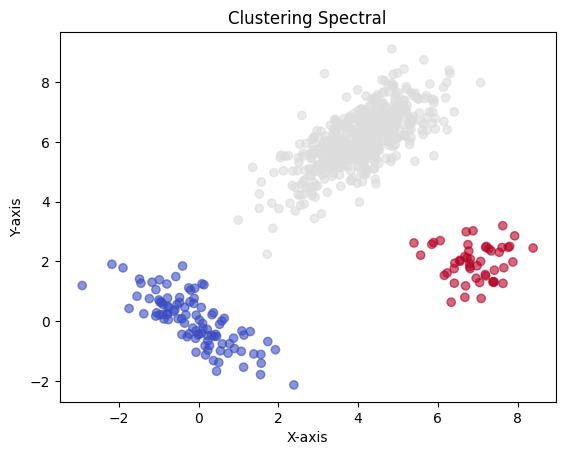

In [25]:
# # YOUR CODE HERE
# def plot_spectral_clustering(X):
#     spectre = get_spectral_clustering(X)
#     plt.scatter(X[:,0],X[:,1],c=spectre.labels_)
#     plt.show()
# plot_spectral_clustering(X_ellipse) 

def plot_spectral_clustering(X):
    '''
    Affiche les points avec une couleur différente selon le clustering spectral
    '''
    spectre = get_spectral_clustering(X)
    labels = spectre.labels_
    
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm', alpha=0.6)
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.title("Clustering Spectral")
    plt.show()
plot_spectral_clustering(X_ellipse)


Nous allons maintenant générer un nouveau ensemble de données en utilisant le code ci-dessous.

In [26]:
def gen_2_moons():
    n_samples = 1500
    noisy_moons = data.make_moons(n_samples=n_samples, noise=.05)
    X = skl.preprocessing.StandardScaler().fit_transform(noisy_moons[0])
    labels = noisy_moons[1]
    
    return X,labels

X_moons,labels_moons = gen_2_moons()

Affichez les nouvelles données

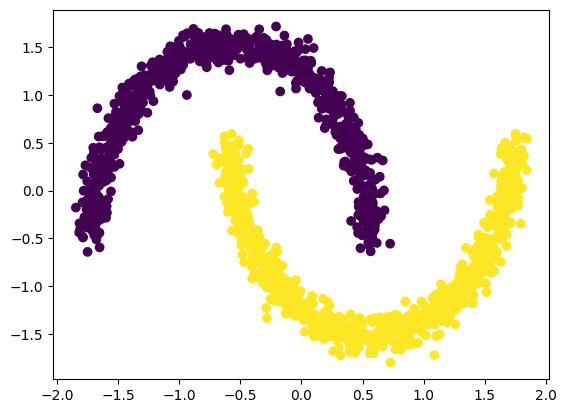

In [27]:
# YOUR CODE HERE
def plot_2_moons(X,labels):
    plt.scatter(X[:,0],X[:,1],c=labels)
    plt.show()
plot_2_moons(X_moons,labels_moons)

Appliquez les différentes méthodes de clustering vu dans ce TP aux données de `X_moons`.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


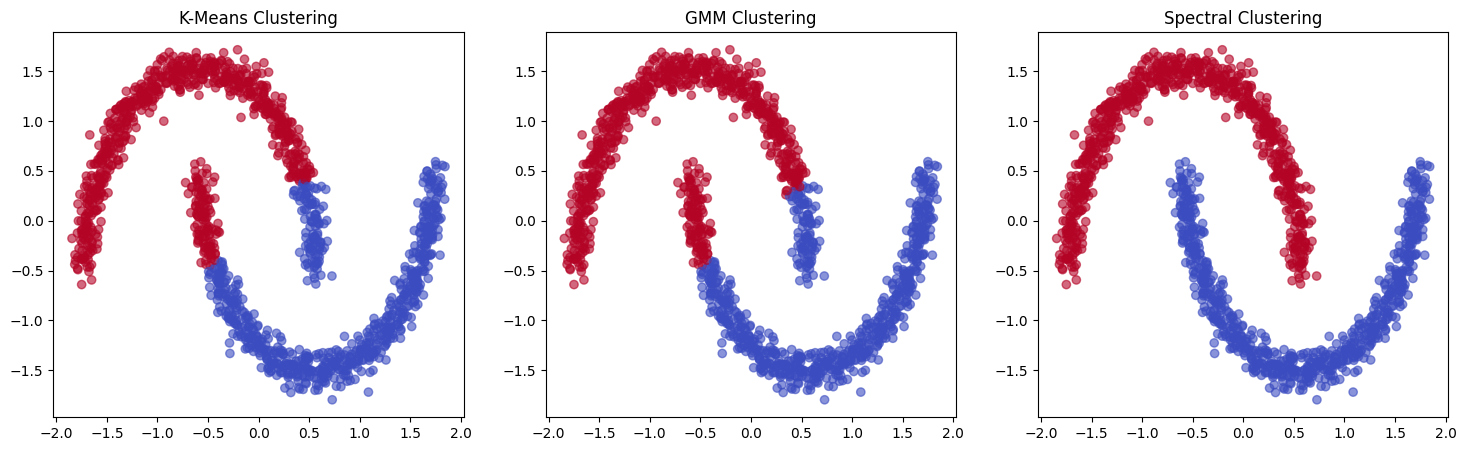

In [28]:
# YOUR CODE HERE
# K-Means 
kmeans_moons = sklearn.cluster.KMeans(n_clusters=2, random_state=42)
kmeans_moons.fit(X_moons)
labels_kmeans_moons = kmeans_moons.labels_

gmm_moons = sklearn.mixture.GaussianMixture(n_components=2, random_state=42)
gmm_moons.fit(X_moons)
labels_gmm_moons = gmm_moons.predict(X_moons)

spectral_moons = sklearn.cluster.SpectralClustering(n_clusters=2, eigen_solver='arpack', affinity='nearest_neighbors', random_state=42)
spectral_moons.fit(X_moons)
labels_spectral_moons = spectral_moons.labels_

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_kmeans_moons, cmap='coolwarm', alpha=0.6)
axs[0].set_title('K-Means Clustering')

axs[1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_gmm_moons, cmap='coolwarm', alpha=0.6)
axs[1].set_title('GMM Clustering')

axs[2].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_spectral_moons, cmap='coolwarm', alpha=0.6)
axs[2].set_title('Spectral Clustering')

plt.show()


5 - Programmation de l'algorithme des K-Moyennes
-----

L'objectif de cette question est de recoder une fonction analogue à celle que vous avez utiliser avec `scikit-learn`. Vous n'êtes donc pas autorisé à utiliser la librairie `scikit-learn` dans cette partie. Votre solution ne doit utiliser que les libraires `numpy` et `scipy`.

Écrivez une fonction *initCentre* qui prend le nombre de centre en paramètre, le nombre de dimension des centres (2 dans les exemples précédent) et retourne des centres tirés selon une loi uniforme entre 0 et 1. Cela correspondra à l’initialisation de l’algorithme.

In [29]:
def initCentre(n,d=2):
    '''
    :param n: nombre de centre
    :param d: dimension de chaque centre
    :return : Retourne n centre de dimension d initialisé aléatoirement selon une loi uniforme
    '''
    # YOUR CODE HERE
    return np.random.rand(n, d)

In [30]:
# Ce bloc permet de valider votre code. Vous ne devez pas le modifier.  
try:
    centre = initCentre(10,5)
    np.testing.assert_equal(centre.shape,(10,5),err_msg="\033[93m {}\033[00m" .format('Test 1 : Les dimensions des centres généres sont incorrect.'))
    
except Exception as e: 
    print("\033[91m {}\033[00m" .format('KO - Au moins un test n\'est pas validé')) 
    print('Information sur le test non valide:')
    print(e)
    raise e
else:
    print("\033[92m {}\033[00m" .format('Ok - Tous les tests sont validés.')) 

 Ok - Tous les tests sont validés.


Faites une fonction `association` qui prend en argument des points et des centres et qui retourne l’association entre chaque point et le numéro du centre le plus proche. Pour réaliser cette fonction, vous pouez utiliser la fonction `cdist` de `scipy` (https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html) . 

In [31]:
def association(p,c):
    '''
    :param p: des points
    :param c: des centres
    :return: l'association de chaque point au centre le plus proch.
    '''
    # YOUR CODE HERE
    distances = sc.spatial.distance.cdist(p, c, 'euclidean')
    return np.argmin(distances, axis=1)

In [32]:
# Ce bloc permet de valider votre code. Vous ne devez pas le modifier.  
try:
    _centre_ = initCentre(10,5)
    _p_ = np.random.randn(100,5)
    _asso_ = association(_p_,_centre_) 
    np.testing.assert_equal(_asso_.shape,(100,),err_msg="\033[93m {}\033[00m" .format('Test 1 : Il doit y avoir une seule association pour chaque point.'))
    np.testing.assert_equal(_asso_.dtype,np.int64,err_msg="\033[93m {}\033[00m" .format('Test 2 : Les associations doivent être des entiers.'))
    
except Exception as e: 
    print("\033[91m {}\033[00m" .format('KO - Au moins un test n\'est pas validé')) 
    print('Information sur le test non valide:')
    print(e)
    raise e
else:
    print("\033[92m {}\033[00m" .format('Ok - Tous les tests sont validés.')) 
    

 Ok - Tous les tests sont validés.


Faites une fonction `updateCentres` qui prend des points, leurs associations à des centres, le nombre de centre et qui retourne la position des nouveauy centres en fonction des associations.
Pour chaque centre vous calculerez le centre moyen des points qui lui ont été associé.  Si aucun point n’a été assigné à ce centre, vous en tirez un nouveau aléatoirement entre 0 et 1. 

Même si cela est faisable sans, vous pouvez utiliser une boucle for et un seul if pour cette question. 

In [33]:
def updateCentres(p,a,nbCenter):
    # YOUR CODE HERE
    new_centers = np.zeros((nbCenter, p.shape[1]))
    for i in range(nbCenter):
        points_associated = p[a == i]
        if len(points_associated) == 0:
            new_centers[i] = np.random.rand(p.shape[1])
        else:
            new_centers[i] = points_associated.mean(axis=0)
    return new_centers

In [34]:
#BONUS: solution sans for et sans if
# YOUR CODE HERE
def updateCentres_no_for_if(p, a, nbCenter):
    # Calculer la somme des points pour chaque centre
    sums = np.array([p[a == i].sum(axis=0) for i in range(nbCenter)])
    
    # Calculer le nombre de points pour chaque centre
    counts = np.array([(a == i).sum() for i in range(nbCenter)])
    
    # Éviter la division par zéro en remplaçant les zéros par un
    counts = np.where(counts == 0, 1, counts)
    
    # Calculer les nouveaux centres
    new_centers = sums / counts[:, np.newaxis]
    
    # Remplacer les centres sans points par des centres aléatoires
    new_centers[counts == 1] = np.random.rand((counts == 1).sum(), p.shape[1])
    
    return new_centers


In [35]:

# Ce bloc permet de valider votre code. Vous ne devez pas le modifier.  
try:
    _centre_ = initCentre(10,5)
    _centre_[4,:] = _centre_[1,:]
    _p_ = np.random.randn(100,5)
    _asso_ = association(_p_,_centre_) 
    new_c = updateCentres(_p_,_asso_,10) 
    np.testing.assert_equal(new_c.shape[0],10,err_msg="\033[93m {}\033[00m" .format('Test 1 : Le nombre de centres générés n\'est pas correct'))
    np.testing.assert_equal(new_c.shape[1],5,err_msg="\033[93m {}\033[00m" .format('Test 2 : La dimension des centres générés n\'est pas correct'))
    np.testing.assert_equal(1e-3 < np.sum((new_c[1,:]-new_c[4,:])**2),True,err_msg="\033[93m {}\033[00m" .format('Test 3 : Il est possible que la gestion des centres ayant aucun point soit incorrect.'))    
    
except Exception as e: 
    print("\033[91m {}\033[00m" .format('KO - Au moins un test n\'est pas validé')) 
    print('Information sur le test non valide:')
    print(e)
    raise e
else:
    print("\033[92m {}\033[00m" .format('Ok - Tous les tests sont validés.')) 
    



 Ok - Tous les tests sont validés.


Créez une fonction *kmeans* implémentant l’algorithme de K-moyennes. Cette fonction prendra comme argument les points d’apprentissage, le nombre de cluster recherché et le nombre d’itération de l’algorithme. Elle retournera les centres trouvés. Vous utiliserez une boucle for pour chaque itération ainsi que les fonctions : *initCentre*, *association* et *updateCentres*.

In [36]:
def kmeans(x, nbCenter, nIteration):
    centers = initCentre(nbCenter, x.shape[1])
    for _ in range(nIteration):
        associations = association(x, centers)
        centers = updateCentres(x, associations, nbCenter)
    return centers

Révision
=======

In [37]:
import os
import gzip
    
import numpy as np
import scipy as sc
from matplotlib import pyplot as plt

import sklearn as sk

from sklearn.datasets import make_moons

from sklearn import svm
from sklearn import linear_model

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

import copy

print(np.__version__)
print(sk.__version__)
print(os.environ['HOME'])
print(os.getcwd())
#print(os.environ['PS1'])

1.26.4
1.6.0
/Users/eldisymeraj
/Users/eldisymeraj/Desktop/M1/S2/Apprentissage/TP/TP2_Clustering


2 -  Création de la base de données 
-----

Nous allons dans ce TP travailler sur une distribution de points sous la forme de "deux lunes" inversées comme dans le TP 2. L'objectif est d'apprendre un classifieur permettant de classer les points, chaque "lune" correspondant à une classe différente.

En utilisant la fonction `make_moons` de `scikit-learn`, créer une base de données de 500 points. Vous prendrez un bruit de $0.2$.

Vous stockerez les points dans une matrice 2D $X$ et les labels dans une variable $y$.

In [38]:
X,y = make_moons(n_samples=500, noise=0.2)
print(X.shape, y.shape)  

(500, 2) (500,)


Affichez sur une figure les points de la base de données. Vous mettrez un couleur différente pour chaque classe.

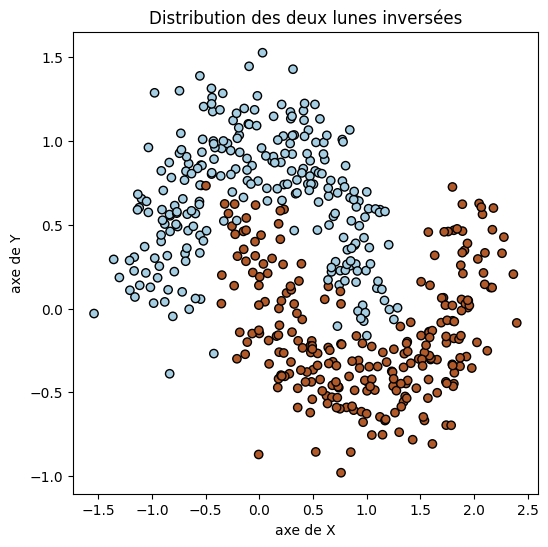

In [39]:
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, edgecolor="k")
#plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', label='Data Points') #on peut utiliser ce modele aussi
plt.xlabel("axe de X")
plt.ylabel("axe de Y")
plt.title("Distribution des deux lunes inversées")
plt.show()

Affichez le nombre d’exemple de la classe 0 et de la classe 1 dans la base en pourcentages.

In [40]:
# Methode 1
# Comptage des occurrences de chaque classe
# unique, counts = np.unique(y, return_counts=True)

# # Calcul des pourcentages
# percentages = (counts / len(y)) * 100

# # Affichage des résultats
# print(f"Classe 0 : {percentages[0]:.2f}% ({counts[0]} exemples)")
# print(f"Classe 1 : {percentages[1]:.2f}% ({counts[1]} exemples)")


# Methode 2
ones = np.count_nonzero(y)
zeros = len(y) - ones

# Calcul des pourcentages
percent_ones = (ones / len(y)) * 100
percent_zeros = (zeros / len(y)) * 100

# Affichage des résultats
print(f"Classe 0 : {percent_zeros:.2f}% ({zeros} exemples)")
print(f"Classe 1 : {percent_ones:.2f}% ({ones} exemples)")



Classe 0 : 50.00% (250 exemples)
Classe 1 : 50.00% (250 exemples)


À votre avis les classes sont-elles équilibrées ? Cela peut-il avoir une importance pour l'apprentissage ? 

Oui, les classes sont équilibrées car le nombre d'éléments de la classe 0 est égal à celui de la classe 1.
Oui, cela peut influencer l'apprentissage, car un bon équilibre évite les biais du modèle vers une classe spécifique.

3 - SVM avec scikit-learn
---------

Découpez la base de données en deux ensembles afin d'avoir 2/3 des exemples pour l’entraînement et 1/3 pour le test. 
Vérifier que les deux ensembles que vous avez créés ont le bon nombre d'exemple.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=(1/3))

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(333, 2)
(167, 2)
(333,)
(167,)


Affichez sur une figure les deux ensembles de points. Vous utiliserez du vert pour la classe 1 et du rouge pour la classe 0. Les exemples de l’ensemble d’apprentissage seront sous la forme de carré et ceux de la base de test sous forme de croix.

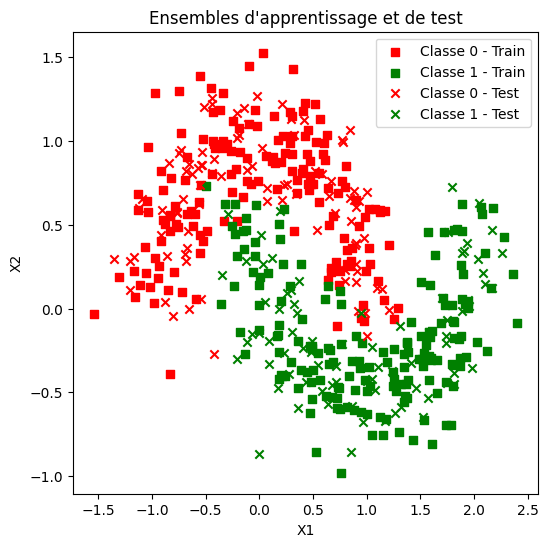

In [42]:
# Création de la figure
plt.figure(figsize=(6,6))

# Affichage des données d'entraînement (carrés)
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='red', marker='s', label="Classe 0 - Train")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='green', marker='s', label="Classe 1 - Train")

# Affichage des données de test (croix)
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], color='red', marker='x', label="Classe 0 - Test")
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], color='green', marker='x', label="Classe 1 - Test")

# Ajout des labels et titre
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Ensembles d'apprentissage et de test")
plt.legend()
plt.show()

Apprenez un classifieur SVM de `scikit-learn` avec les paramètres par défaut.

In [43]:
# Création et entraînement du modèle SVM avec les paramètres par défaut
svm_model = svm.SVC()  
svm_model.fit(X_train, y_train)
print(svm_model)


SVC()


Faites la prédiction sur la base de test et donnez les performances vis à vis du critère d'`accuracy`.

In [44]:
from sklearn.metrics import accuracy_score
# Prédiction sur l'ensemble de test
y_pred = svm_model.predict(X_test)

# Calcul de l'accuracy
accuracy = accuracy_score(y_test, y_pred)

# Affichage du résultat
print(f"Accuracy du modèle SVM sur l'ensemble de test : {accuracy:.2f}")


Accuracy du modèle SVM sur l'ensemble de test : 0.96


In [45]:
print(np.mean(y_test == 1))
print(np.mean(y_test == 0))

0.47305389221556887
0.5269461077844312


Quelles sont les performances d’un classifieur répondant:
- au hasard, 
- toujours la classe 1,
- toujours la classe 0.

**Réponse**
- au hasard :  50% car il choisit aléatoirement entre 0 et 1
- toujours la classe 1 : 50% car 50% des données sont de classe 1
- toujours la classe 0 : 50% car 50% des données sont de classe 0

En utilisant un code similaire au TP2 et au TP3, affichez avec deux couleurs différentes les zones associés à chaque classe retournée par le classifieur que vous venez d'apprendre.

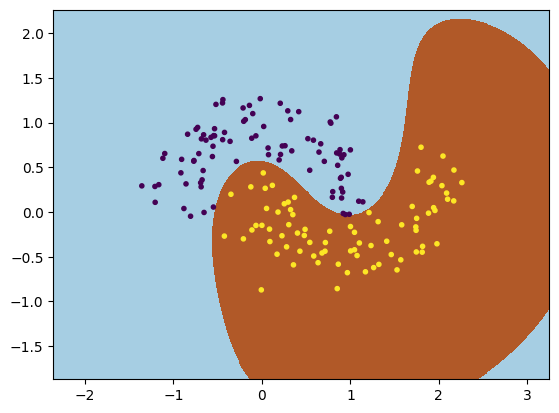

In [46]:
def affichage_cellules_Voronoi(clf,X,labels):
    '''
    Fonction affichant les cellules de Voronoi d'un algorithme de clustering préalablement appris
    :param clf: classifieur non supervisé appris au préalable
    '''
    pas = 500 # pas de quantification, plus la valeur est grande plus les frontières sont précises mais le temps de calcul augmente

    x_min, x_max = X[:, 0].min() -1, X[:, 0].max() +1
    y_min, y_max = X[:, 1].min() -1 , X[:, 1].max() +1
    h = abs(x_max-x_min)/pas 
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = clf.predict(np.stack((xx.ravel(), yy.ravel()),1))
    Z = Z.reshape(xx.shape)

    plt.scatter(X[:,0],X[:,1],c=labels,marker='.')
    plt.imshow(Z, interpolation='nearest',
               extent=(xx.min(), xx.max(), yy.min(), yy.max()),
               cmap=plt.cm.Paired,
               aspect='auto', origin='lower')
    plt.show()

affichage_cellules_Voronoi(svm_model,X_test,y_pred)

Faites une cross-validation des paramètres d'un SVM linéaire pour les valeurs de C suivantes: 1e-2 , 1e-1 , 1. Vous utiliserez comme critère de score, l'aire sous la courbe de précision/rappel.

In [47]:
# le clf moi je l'ai nomé svm_model

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Définition des hyperparamètres à tester
param_grid = { 'C': [1e-2, 1e-1, 1.], }

# Création d'un classifieur SVM linéaire
svm_linear = SVC(kernel='linear')

# Grid Search avec cross-validation (cv=5) et aire sous la courbe précision/rappel
grid_search = GridSearchCV(svm_linear, param_grid, scoring='average_precision', cv=5)

# Entraînement
grid_search.fit(X_train, y_train)

# Affichage des meilleurs paramètres et score
print("Best Parameters:", grid_search.best_params_)
print("Best Score (AUC PR):", grid_search.best_score_)



Best Parameters: {'C': 1.0}
Best Score (AUC PR): 0.9552510337594976


Récupérez le meilleur classifieur et placez le dans une variable `clf_best`.

In [48]:
clf_best = grid_search.best_estimator_
y_pred_new = clf_best.predict(X_test)

Affichez avec deux couleurs différentes les zones associées à chaque classe retournée par le meilleur classifieur que vous venez de trouver.

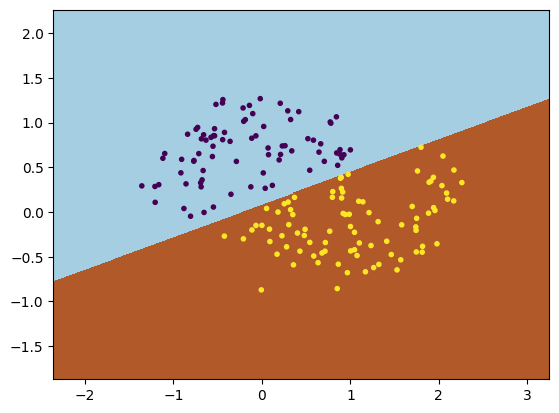

In [49]:
def affichage_cellules_Voronoi(clf,X,labels):
    '''
    Fonction affichant les cellules de Voronoi d'un algorithme de clustering préalablement appris
    :param clf: classifieur non supervisé appris au préalable
    '''
    pas = 500 # pas de quantification, plus la valeur est grande plus les frontières sont précises mais le temps de calcul augmente

    x_min, x_max = X[:, 0].min() -1, X[:, 0].max() +1
    y_min, y_max = X[:, 1].min() -1 , X[:, 1].max() +1
    h = abs(x_max-x_min)/pas 
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = clf.predict(np.stack((xx.ravel(), yy.ravel()),1))
    Z = Z.reshape(xx.shape)

    plt.scatter(X[:,0],X[:,1],c=labels,marker='.')
    plt.imshow(Z, interpolation='nearest',
               extent=(xx.min(), xx.max(), yy.min(), yy.max()),
               cmap=plt.cm.Paired,
               aspect='auto', origin='lower')
    plt.show()

affichage_cellules_Voronoi(clf_best,X_test,y_pred_new)

# 4 - SVM à l’aide de l’algorithme SMO

En complétant le code suivant, ré-implémentez un SVM à l’aide de l'algorithme SMO. 

In [50]:
import random

def tirage_without(n, j):
    random_number = random.randint(0, n - 2)
    if random_number >= j:
        random_number += 1
    return np.int64(random_number)

In [51]:
import numpy as np
import random

def f(x, v_supports, y_supports, alphas, b):
    '''
    Calcul le résultat d'un classifieur SVM pour des exemples.
    :param x: exemple(s) que l'on souhaite évaluer. Chaque ligne correspond à un exemple. Dans le cas où il n'y a qu'un exemple, les dimensions sont (1,dimension du descripteur).
    :param v_supports: exemples de la base d'apprentissage ou vecteurs supports appris
    :param y_supports: labels des exemples d'apprentissage ou des vecteurs supports sélectionnés
    :param alphas: poids des vecteurs supports, les valeurs peuvent être nulle si toute la base d'apprentissage est donnée.
    :param b: paramètre de biais
    :return: le résultat de classification pour les exemples de x. f(x) = ∑ alpha_i y_i <x_i,y> + b
    '''
    # Compute the dot product between input vector x and support vectors
    dot_products = np.dot(v_supports, x.T)
    
    # Compute the decision function
    decision = np.dot(alphas * y_supports, dot_products) + b
    
    return decision

In [52]:
class SVM:
    def __init__(self, 
                 C=1e0,
                 tol=1e-4,
                 maxIter=50
                ):
        """
        :param C: paramètre de régularisation
        :param tol: tolérance sur le respect des contraintes
        :param maxIter: nombre maximale d'itération de l'algorithme.
        """
        self.C = C
        self.tol = tol
        self.maxIter = maxIter

        self.alphas = None
        self.b = None
        self.v_supports = None
        self.y_supports = None

    def __tirage_without(self,n,i):
        '''
        Tirage d'un nombre entre 0 et n non compris et différent de i.
        '''
        random_number = random.randint(0, n - 2)
        
        if random_number >= i:
            random_number += 1
        return random_number
    
    
    def fit(self,X,y):
        '''
        :param X: X données d'apprentissage. Chaque ligne correspond à un exemple.
        :param y: y labels des exemples d'apprentissage (-1 ou 1).        
        :return : retourne les poids des vecteurs suppérieurs (alphas) et le bias (b) du classifieur. Les poids sont à 0 pour les exemples d'apprentissages qui ne sont pas vecteur support.
        '''
        m,n = X.shape

        #transformation en -1 et 1
        y = y*2-1
        
        # Initialisation du classifieur
        self.b = 0
        #self.alphas = np.zeros(X.shape[0])
        self.alphas = np.zeros(m)
        self.v_supports = X.copy()
        self.y_supports = y.copy()
        
        for t in range(self.maxIter):
            alphaPairsChanged = 0
            for i in range(m):
                
                # Évaluation de la fonction pour l'exemple i (fXi)
                
                fXi = f(X[i,None,:],X,y,self.alphas,self.b)
                
                # Erreur de l'exemple i (Ei)
                # Ei = abs(fXi - y[i])
                Ei = fXi - y[i]
                
                # Si la contraintes n'est pas saturé et que |Ei|>tolerance
                if ((y[i] * Ei < -self.tol and self.alphas[i] < self.C) or
                    (y[i] * Ei > self.tol and self.alphas[i] > 0)):
                    
                    # Tirage aléatoire du deuxième points différent du premier et calcul de fXj et Ej.
                    j = self.__tirage_without(m, i)
                    
                    fXj = f(X[j,None,:],X,y,self.alphas,self.b)
                    #Ej = abs(fXj - y[j])
                    Ej = fXj - y[j]
                    
                    alphaIold = self.alphas[i]
                    alphaJold = self.alphas[j]
                    
                    if y[i] != y[j]:
                        L = max(0, self.alphas[j] - self.alphas[i])
                        H = min(self.C, self.C + self.alphas[j] - self.alphas[i])
                    else:
                        L = max(0, self.alphas[j] + self.alphas[i] - self.C)
                        H = min(self.C, self.alphas[j] + self.alphas[i])

                    if L == H:
                        continue       
                        
                    # Calcul de Eta
                    eta = -2 * np.dot(X[i], X[j]) + np.linalg.norm(X[i])**2 + np.linalg.norm(X[j])**2


                    # Passe à l'iteration suivante de la boucle for si eta est négatif
                    if eta <= 0:
                        continue
    
                    # Mise à jour de alpha_j. Changez directement alphas[j].
                    self.alphas[j] += y[j] * (Ei - Ej) / eta
                    self.alphas[j] = np.clip(self.alphas[j], L, H)
                    
                    if np.abs(self.alphas[j]-alphaJold)<0.00001:
                        continue
                    # Mise à jour de alpha_i. Changez directement alphas[i].
                    self.alphas[i] += y[i] * y[j] * (alphaJold - self.alphas[j])
                    
                    # Calcul de b
                    #C = 1

                    b1 = (self.b - Ei - y[i] * (self.alphas[i] - alphaIold) * np.linalg.norm(X[i])**2
                          - y[j] * (self.alphas[j] - alphaJold) * np.dot(X[i], X[j]))
                    
                    b2 = (self.b - Ej - y[j] * (self.alphas[j] - alphaJold) * np.linalg.norm(X[j])**2
                          - y[i] * (self.alphas[i] - alphaIold) * np.dot(X[i], X[j]))

                    # Compute the new value of b
                    if 0 < self.alphas[i] < self.C:
                        self.b = b1
                    elif 0 < self.alphas[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2

        return self

    def forward(self,x):
        '''
        Calcul le résultat d'un classifieur SVM pour des exemples.
        :param x: exemple(s) que l'on souhaite évaluer. Chaque ligne correspond à un exemple. Dans le cas où il n'y a qu'un exemple, les dimensions sont (1,dimension du descripteur).
        :return: le résultat de classification pour les exemples de x. f(x) = \sum alpha_i y_i <x_i,y> + b
        '''
        #return np.sum(self.alphas * self.y * (x @ y) + b)
        return np.dot(self.alphas * self.y_supports, np.dot(self.v_supports, x.T)) + self.b
       
    def predict(self,x):
        '''
        Retourne les labels prédient par le SVM. Correspond aux signes des valeurs retournées par la méthode forward.
        '''
        # return self.forward(x)>0
        return np.sign(self.forward(x))

<>:123: SyntaxWarning: invalid escape sequence '\s'
<>:123: SyntaxWarning: invalid escape sequence '\s'
/var/folders/wb/9zflx0n97vq_xb4zjp92blmw0000gn/T/ipykernel_32055/1886031500.py:123: SyntaxWarning: invalid escape sequence '\s'
  '''


Donnez les performances en accuracy que vous obtenez pour les ensembles de train et test ?

In [53]:
# new_clf = SVM()
# new_clf = new_clf.fit(X_train,y_train)

# Instanciation du modèle
svm_smo = SVM(C=1.0, tol=1e-4, maxIter=50)

# Entraînement sur les données d'entraînement
svm_smo.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

# Prédictions sur l'ensemble d'entraînement et de test
y_train_pred = svm_smo.predict(X_train)
y_test_pred = svm_smo.predict(X_test)

# Calcul de l'accuracy
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

# Affichage des résultats
print(f"Accuracy sur l'ensemble d'entraînement : {accuracy_train:.2f}")
print(f"Accuracy sur l'ensemble de test : {accuracy_test:.2f}")


/var/folders/wb/9zflx0n97vq_xb4zjp92blmw0000gn/T/ipykernel_32055/1886031500.py:95: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.alphas[j] += y[j] * (Ei - Ej) / eta


Accuracy sur l'ensemble d'entraînement : 0.44
Accuracy sur l'ensemble de test : 0.42


Définissez une fonction `compute_kernel` permettant de calculer le noyau gaussien deux matrices de points. Pour rappel, $k(i_i,x_j)=\exp\left(-\dfrac{\|x_i-x_j\|^2}{2\sigma^2}\right)$ avec $\sigma\in\mathbb{R}^{+}$. 

In [54]:
def compute_kernel(sigma,X_i,X_j):
    return np.exp(-1 * (numpy.linalg.norm(X_i - X_j)**2) / (2*(sigma**2)))


Redéfinissez la class `SVM` en complétant le code suivant pour implémenter un SVM avec un noyau gaussien. Pour cela, utiliser l’astuce du noyau et la fonction de la question précédante.

In [55]:
class SVM_gaussian:
    def __init__(self, 
                 C=1e0,
                 sigma=1e0,
                 tol=1e-4,
                 maxIter=50
                ):
        """
        :param C: paramètre de régularisation
        :param tol: tolérance sur le respect des contraintes
        :param maxIter: nombre maximale d'itération de l'algorithme.
        """
        self.C = C
        self.sigma = sigma
        self.tol = tol
        self.maxIter = maxIter

        self.alphas = None
        self.b = None
        self.v_supports = None
        self.y_supports = None

    def __tirage_without(self,n,i):
        random_number = random.randint(0, n - 2)
        
        if random_number >= i:
            random_number += 1
        return random_number
    
    def fit(self,X,y):
        '''
        :param X: X données d'apprentissage. Chaque ligne correspond à un exemple.
        :param y: y labels des exemples d'apprentissage (-1 ou 1).        
        :return : retourne les poids des vecteurs suppérieurs (alphas) et le bias (b) du classifieur. Les poids sont à 0 pour les exemples d'apprentissages qui ne sont pas vecteur support.
        '''
        ### Your Code Here
        m, n = X.shape
        y = y * 2 - 1  
        self.b = 0
        self.alphas = np.zeros(m)
        self.v_supports = X.copy()
        self.y_supports = y.copy()

        for t in range(self.maxIter):
            for i in range(m):
                #calcul de fXi avec un noyau gausssien
                K = np.exp(-np.linalg.norm(X[i] - X, axis=1) ** 2 / (2 * self.sigma ** 2))
                fXi = np.dot(self.alphas * y, K) + self.b
                Ei = fXi - y[i]

                if ((y[i] * Ei < -self.tol and self.alphas[i] < self.C) or
                    (y[i] * Ei > self.tol and self.alphas[i] > 0)):

                    j = self.__tirage_without(m, i)
                    Kj = np.exp(-np.linalg.norm(X[j] - X, axis=1) ** 2 / (2 * self.sigma ** 2))
                    fXj = np.dot(self.alphas * y, Kj) + self.b
                    Ej = fXj - y[j]

                    alphaIold = self.alphas[i]
                    alphaJold = self.alphas[j]

                    if y[i] != y[j]:
                        L = max(0, self.alphas[j] - self.alphas[i])
                        H = min(self.C, self.C + self.alphas[j] - self.alphas[i])
                    else:
                        L = max(0, self.alphas[j] + self.alphas[i] - self.C)
                        H = min(self.C, self.alphas[j] + self.alphas[i])

                    if L == H:
                        continue

                    eta = 2 * np.exp(-np.linalg.norm(X[i] - X[j]) ** 2 / (2 * self.sigma ** 2)) - \
                          np.exp(0) - np.exp(0)
                    if eta >= 0:
                        continue

                    self.alphas[j] -= y[j] * (Ei - Ej) / eta
                    self.alphas[j] = np.clip(self.alphas[j], L, H)

                    if abs(self.alphas[j] - alphaJold) < 1e-5:
                        continue

                    self.alphas[i] += y[i] * y[j] * (alphaJold - self.alphas[j])

                    #je mets a jour b
                    b1 = self.b - Ei - y[i] * (self.alphas[i] - alphaIold) * np.exp(0) - \
                         y[j] * (self.alphas[j] - alphaJold) * np.exp(-np.linalg.norm(X[i] - X[j]) ** 2 / (2 * self.sigma ** 2))
                    b2 = self.b - Ej - y[j] * (self.alphas[j] - alphaJold) * np.exp(0) - \
                         y[i] * (self.alphas[i] - alphaIold) * np.exp(-np.linalg.norm(X[i] - X[j]) ** 2 / (2 * self.sigma ** 2))

                    if 0 < self.alphas[i] < self.C:
                        self.b = b1
                    elif 0 < self.alphas[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2
        return self

    def forward(self,x):
        #Prediction
        '''
        Calcul le résultat d'un classifieur SVM pour des exemples.
        :param x: exemple(s) que l'on souhaite évaluer. Chaque ligne correspond à un exemple. Dans le cas où il n'y a qu'un exemple, les dimensions sont (1,dimension du descripteur).
        :return: le résultat de classification pour les exemples de x. f(x) = \sum alpha_i y_i <x_i,y> + b
        '''
        result = np.zeros(x.shape[0])
        for i in range(x.shape[0]):
            K = np.exp(-np.linalg.norm(self.v_supports - x[i], axis=1) ** 2 / (2 * self.sigma ** 2))
            result[i] = np.dot(self.alphas * self.y_supports, K) + self.b
        return result
    
    def predict(self,x):
        ### Your Code Here
        return np.sign(self.forward(x))

<>:101: SyntaxWarning: invalid escape sequence '\s'
<>:101: SyntaxWarning: invalid escape sequence '\s'
/var/folders/wb/9zflx0n97vq_xb4zjp92blmw0000gn/T/ipykernel_32055/1446768900.py:101: SyntaxWarning: invalid escape sequence '\s'
  '''


Quelles performances obtenez vous avec cette nouvelle implémentation ? 

In [56]:
svm_gauss = SVM_gaussian(C=1.0, sigma=0.5, tol=1e-4, maxIter=50)

#entrainement
svm_gauss.fit(X_train, y_train)

#predicitions
y_pred_train = svm_gauss.predict(X_train)
y_pred_test = svm_gauss.predict(X_test)

# evaluation

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"accuracy sur l'ensemble d'entrainement: {acc_train:.2f}")
print(f"accuracy sur l'ensemble de test: {acc_test:.2f}")


accuracy sur l'ensemble d'entrainement: 0.49
accuracy sur l'ensemble de test: 0.46


Affichez avec deux couleurs différentes les zones associées à chaque classe retournée par vorte code pour $\sigma=10$, $\sigma=1$, $\sigma=0.1$.

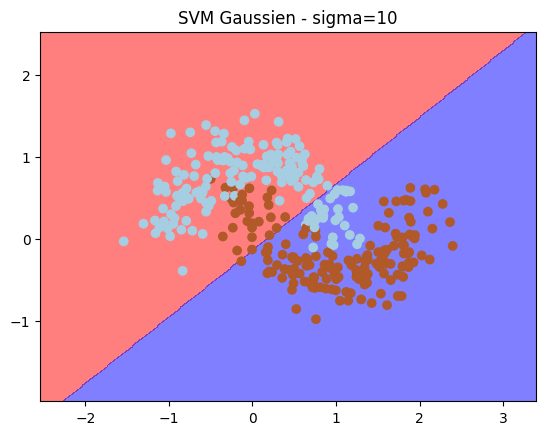

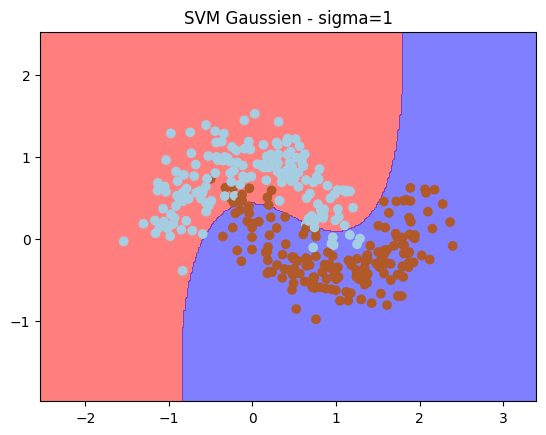

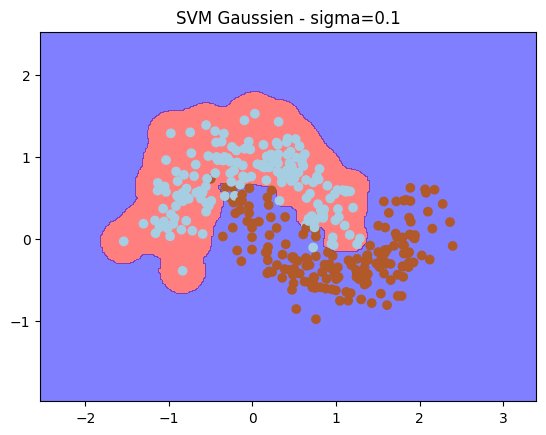

In [57]:
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 300),
                     np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 300))

for sigma_val in [10, 1, 0.1]:
    svm_gauss = SVM_gaussian(C=1.0, sigma=sigma_val, tol=1e-4, maxIter=50)
    svm_gauss.fit(X_train, y_train)

    # prediction
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = svm_gauss.predict(grid_points)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.5, colors=['red', 'blue'])
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.Paired)
    plt.title(f"SVM Gaussien - sigma={sigma_val}")
    plt.show()


Que peut-on en déduire de l’influence du paramètres $\sigma$ ?

Le paramètre sigma joue sur la forme de la frontière. Quand sigma est grand la frontiere est presque droite et le modele ne suit pas bien les donnees. Quand sigma est petit la frontiere devient tres compliquée et suit trop les points d’apprentissage ce qui peut etre mauvais pour les nouveaux points.il faut choisir un sigma qui equilibre bien entre suivre les donnees et bien généraliser